In [7]:
# !pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 9.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of notebook to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.8/109.8 kB 13.0 

In [1]:
# import tensorflow as tf

# print("TensorFlow :", tf.__version__)
# print("GPU :", tf.config.list_physical_devices("GPU"))

TensorFlow : 2.19.0
GPU : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# from google.colab import drive
# drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# import os

# os.environ["DATASET_ROOT"] = "/content/drive/MyDrive/VDD_Dataset"
# os.environ["MODEL_ROOT"] = "/content/drive/MyDrive/VDD_Dataset"
# os.environ["OUTPUT_ROOT"] = "/content/drive/MyDrive/VDD_Dataset"
# os.environ["LOG_ROOT"] = "/content/drive/MyDrive/VDD_Dataset"

# print(os.environ["DATASET_ROOT"])

/content/drive/MyDrive/VDD_Dataset


In [4]:
# # clone this repo
# !rm -rf /content/VDD_ComparativeAnalysis
# !git clone https://github.com/pri-13/VDD_ComparativeAnalysis.git

Cloning into 'VDD_ComparativeAnalysis'...
remote: Enumerating objects: 52, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 52 (delta 18), reused 33 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (52/52), 8.18 MiB | 20.42 MiB/s, done.
Resolving deltas: 100% (18/18), done.


In [5]:
# # go to the folder
# %cd VDD_ComparativeAnalysis

/content/VDD_ComparativeAnalysis


In [6]:
#imports
from src.config import *
from src.dataset import create_dataset, optimize_dataset
from src.models import get_model
from src.trainer import train_model
from src.utils import create_project_dirs, set_seed

In [7]:
create_project_dirs()
set_seed(RANDOM_SEED)

print("Project initialized successfully.")

Project initialized successfully.


In [8]:
#load dataset
train_dataset = create_dataset(TRAIN_DIR)
validation_dataset = create_dataset(VAL_DIR, shuffle=False)
CLASS_LABELS = train_dataset.class_names
print(CLASS_LABELS)
print(f"Number of Classes : {len(CLASS_LABELS)}")

Found 4371 files belonging to 6 classes.
Found 1237 files belonging to 6 classes.
['crack', 'dent', 'glass shatter', 'lamp broken', 'scratch', 'tire flat']
Number of Classes : 6


In [9]:
#optimize dataset
train_dataset = optimize_dataset(train_dataset)
validation_dataset = optimize_dataset(validation_dataset)
print("Dataset optimized successfully.")

Dataset optimized successfully.


In [10]:
#verify batch
images, labels = next(iter(train_dataset))
print(images.shape)
print(labels.shape)
print(images.dtype)

(32, 224, 224, 3)
(32,)
<dtype: 'float32'>


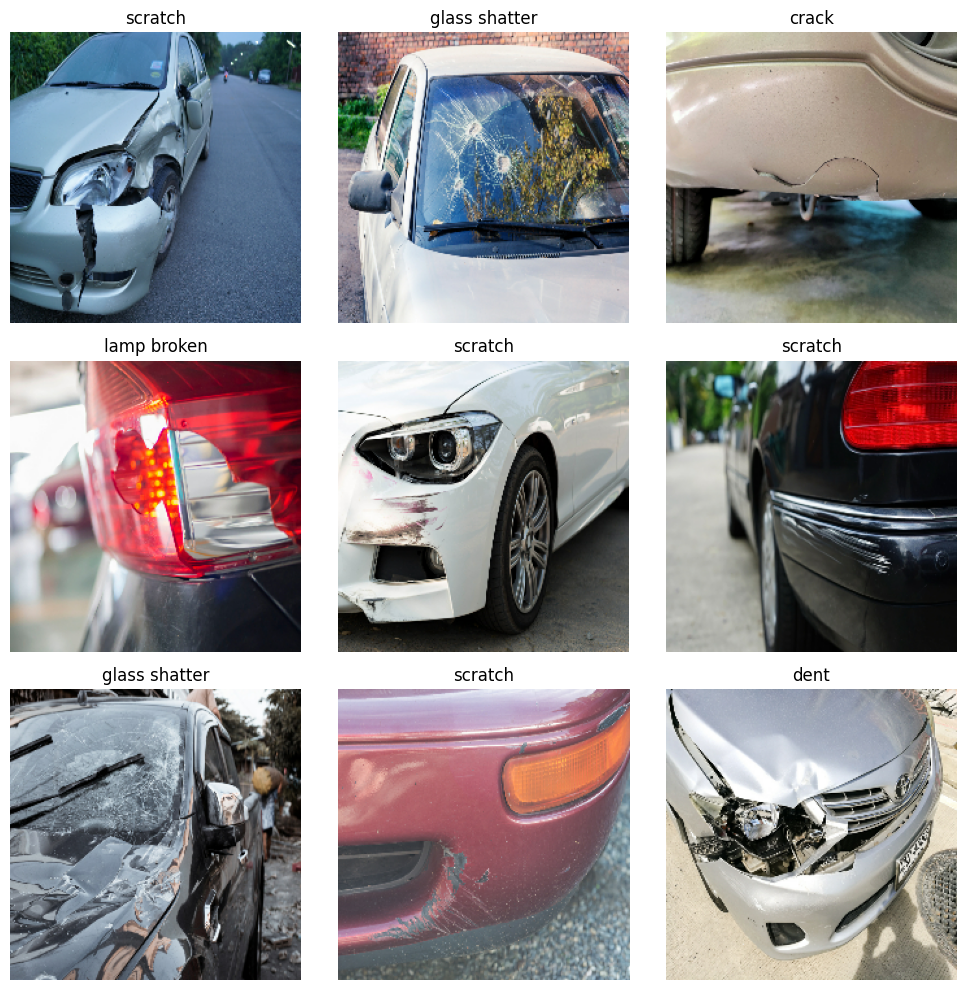

In [11]:
#display sample images
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(CLASS_LABELS[labels[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [12]:
#training loop
from pathlib import Path

for model_name in MODELS:
    model_path = SAVED_MODELS_DIR / f"{model_name}.keras"
    if model_path.exists():
        print(f"Skipping {model_name}")
        continue
    print(f"Training : {model_name}")
    model = get_model(model_name)
    history = train_model(
        model=model,
        train_dataset=train_dataset,
        validation_dataset=validation_dataset,
        model_name=model_name
    )
    print(f"{model_name} completed.\n")

Skipping custom_cnn
Skipping vgg16
Skipping mobilenetv2
Training : densenet121
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.2606 - loss: 2.0223 
Epoch 1: val_accuracy improved from None to 0.35327, saving model to /content/drive/MyDrive/VDD_Dataset/saved_models/densenet121.keras
137/137 ━━━━━━━━━━━━━━━━━━━━ 1955s 14s/step - accuracy: 0.2855 - loss: 1.9238 - val_accuracy: 0.3533 - val_loss: 1.5805 - learning_rate: 1.0000e-04
Epoch 2/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 580ms/step - accuracy: 0.3097 - loss: 1.8084
Epoch 2: val_accuracy improved from 0.35327 to 0.38319, saving model to /content/drive/MyDrive/VDD_Dataset/saved_models/densenet121.keras
137/137 ━━━━━━━━━━━━━━━━━━━━ 104s 757ms/step - accuracy: 0.3274 - loss: 1.7329 - val_accuracy: 0.3832 - val_loss: 1.4627 - learning_rate: 1.0000e-04
Epoch 3/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 807ms/step - accuracy: 0.3511 - loss: 1.6643
Epoch 3: val_accuracy improved from 0

ValueError: Shape mismatch in layer #1 (named stem_conv)for weight stem_conv/kernel. Weight expects shape (3, 3, 1, 32). Received saved weight with shape (3, 3, 3, 32)

In [13]:
print("Training completed successfully.")
print("\nSaved Models:")
print(SAVED_MODELS_DIR)
print("\nTraining Outputs:")
print(TRAINING_OUTPUT_DIR)

Training completed successfully.

Saved Models:
/content/drive/MyDrive/VDD_Dataset/saved_models

Training Outputs:
/content/drive/MyDrive/VDD_Dataset/outputs/training


In [14]:
#saving models
print("Saved Models")
for file in Path(SAVED_MODELS_DIR).glob("*"):
    print(file.name)
print()
print("Training Outputs")
for file in Path(TRAINING_OUTPUT_DIR).glob("*"):
    print(file.name)

Saved Models
custom_cnn.keras
vgg16.keras
mobilenetv2.keras
densenet121.keras

Training Outputs
custom_cnn_history.csv
custom_cnn_training_info.csv
vgg16_history.csv
vgg16_training_info.csv
mobilenetv2_history.csv
mobilenetv2_training_info.csv
densenet121_history.csv
densenet121_training_info.csv
